## Outlier Detection
### Author: Bao Khoi Bui
### UH ID: 2060524

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('owid_covid_data.csv')  
data = data[['date', 'location', 'new_cases', 'new_deaths', 'hosp_patients']]  
data['date'] = pd.to_datetime(data['date'])
data = data.dropna()  
print(data.head())

#Define pre- and post-vaccination periods
vaccination_start_date = '2021-01-01'
pre_vaccination = data[data['date'] < vaccination_start_date]
post_vaccination = data[data['date'] >= vaccination_start_date]


            date   location  new_cases  new_deaths  hosp_patients
21862 2020-03-31  Australia        0.0         0.0          426.0
21863 2020-04-01  Australia        0.0         0.0          441.0
21864 2020-04-02  Australia        0.0         0.0          415.0
21865 2020-04-03  Australia        0.0         0.0          457.0
21866 2020-04-04  Australia        0.0         0.0          490.0


### Z-Score Outlier Detection Test

In [5]:
def detect_outliers_zscore(data, column):
    threshold = 3
    mean = data[column].mean()
    std = data[column].std()
    z_scores = (data[column] - mean) / std
    return data[abs(z_scores) > threshold]

### IQR Outlier Detection Test

In [6]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

### Outlier Detection in Pre vs. Post Vaccination Infections

In [7]:
#Detect outliers using Z-Score
infections_pre_vaccination = detect_outliers_zscore(pre_vaccination, 'new_cases')
infections_post_vaccination = detect_outliers_zscore(post_vaccination, 'new_cases')

#Detect outliers using IQR 
infections_pre_vaccination_iqr = detect_outliers_iqr(pre_vaccination, 'new_cases')
infections_post_vaccination_iqr = detect_outliers_iqr(post_vaccination, 'new_cases')

print(f"Number of Z-Score Outliers - Pre-Vaccination: {len(infections_pre_vaccination)}")
print(f"Number of Z-Score Outliers - Post-Vaccination: {len(infections_post_vaccination)}")

print(f"Number of IQR Outliers - Pre-Vaccination: {len(infections_pre_vaccination_iqr)}")
print(f"Number of IQR Outliers - Post-Vaccination: {len(infections_post_vaccination_iqr)}")

Number of Z-Score Outliers - Pre-Vaccination: 46
Number of Z-Score Outliers - Post-Vaccination: 235
Number of IQR Outliers - Pre-Vaccination: 1119
Number of IQR Outliers - Post-Vaccination: 4025


### Outlier Detection in Pre vs. Post Vaccination Hospitalization

In [8]:
#Detect outliers using Z-Score
hospitalization_pre_vaccination = detect_outliers_zscore(pre_vaccination, 'hosp_patients')
hospitalization_post_vaccination = detect_outliers_zscore(post_vaccination, 'hosp_patients')

#Detect outliers using IQR
hospitalization_pre_vaccination_iqr = detect_outliers_iqr(pre_vaccination, 'hosp_patients')
hospitalization_post_vaccination_iqr = detect_outliers_iqr(post_vaccination, 'hosp_patients')

print(f"Number of Z-Score Outliers - Pre-Vaccination: {len(hospitalization_pre_vaccination)}")
print(f"Number of Z-Score Outliers - Post-Vaccination: {len(hospitalization_post_vaccination)}")

print(f"Number of IQR Outliers - Pre-Vaccination: {len(hospitalization_pre_vaccination_iqr)}")
print(f"Number of IQR Outliers - Post-Vaccination: {len(hospitalization_post_vaccination_iqr)}")

Number of Z-Score Outliers - Pre-Vaccination: 128
Number of Z-Score Outliers - Post-Vaccination: 408
Number of IQR Outliers - Pre-Vaccination: 1044
Number of IQR Outliers - Post-Vaccination: 3527


### Outlier Detection in Pre vs. Post Vaccination Mortality

In [9]:
#Detect outliers using Z-Score
mortality_pre_vaccination = detect_outliers_zscore(pre_vaccination, 'new_deaths')
mortality_post_vaccination = detect_outliers_zscore(post_vaccination, 'new_deaths')

#Detect outliers using IQR 
mortality_pre_vaccination_iqr = detect_outliers_iqr(pre_vaccination, 'new_deaths')
mortality_post_vaccination_iqr = detect_outliers_iqr(post_vaccination, 'new_deaths')

print(f"Number of Z-Score Outliers - Pre-Vaccination: {len(mortality_pre_vaccination)}")
print(f"Number of Z-Score Outliers - Post-Vaccination: {len(mortality_post_vaccination)}")

print(f"Number of IQR Outliers - Pre-Vaccination: {len(mortality_pre_vaccination_iqr)}")
print(f"Number of IQR Outliers - Post-Vaccination: {len(mortality_post_vaccination_iqr)}")

Number of Z-Score Outliers - Pre-Vaccination: 78
Number of Z-Score Outliers - Post-Vaccination: 214
Number of IQR Outliers - Pre-Vaccination: 995
Number of IQR Outliers - Post-Vaccination: 3840


### Pre vs. Post Vaccination Infection Scatterplots

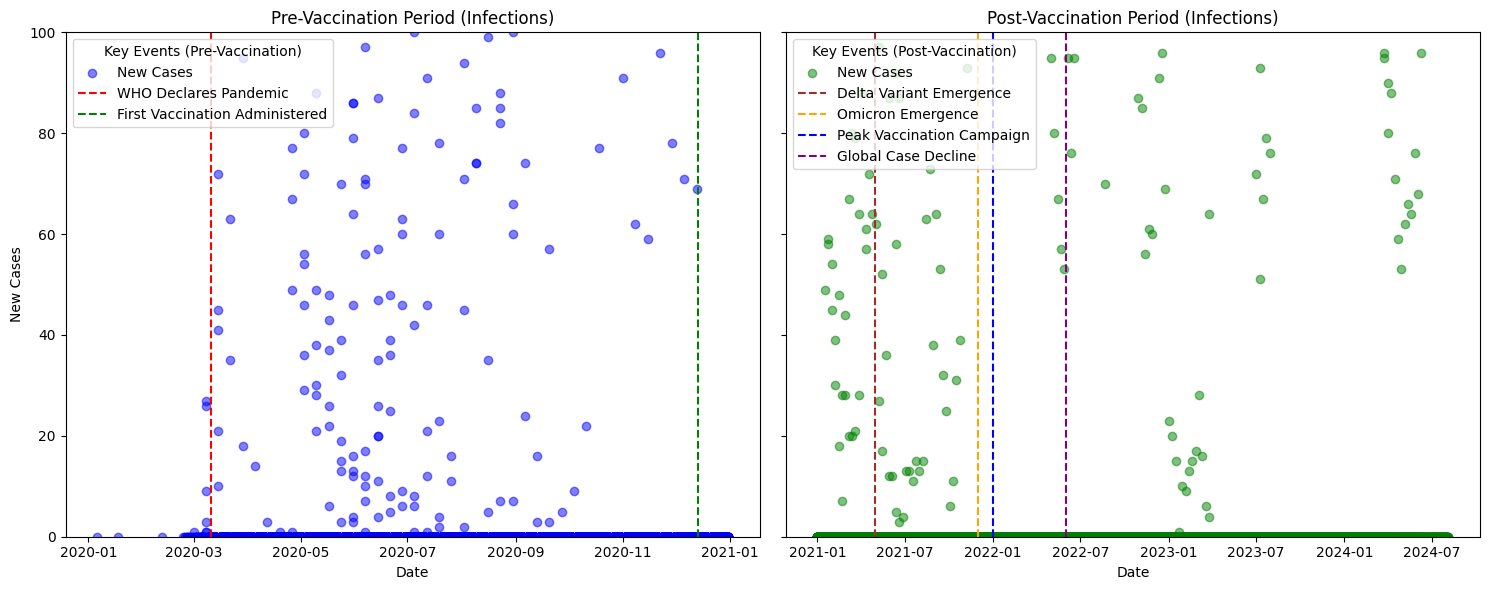

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

#Scatterplot for pre-vaccination
axes[0].scatter(pre_vaccination['date'], pre_vaccination['new_cases'], alpha=0.5, color='blue', label='New Cases')
axes[0].set_title("Pre-Vaccination Period (Infections)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("New Cases")
axes[0].set_ylim(0, 100)

#Scatterplot for post-vaccination
axes[1].scatter(post_vaccination['date'], post_vaccination['new_cases'], alpha=0.5, color='green', label='New Cases')
axes[1].set_title("Post-Vaccination Period (Infections)")
axes[1].set_xlabel("Date")
axes[1].set_ylim(0, 100)

#key events
key_events = {
    '2020-03-11': {'label': 'WHO Declares Pandemic', 'color': 'red', 'subplot': 0},
    '2020-12-14': {'label': 'First Vaccination Administered', 'color': 'green', 'subplot': 0},
    '2021-05-01': {'label': 'Delta Variant Emergence', 'color': 'brown', 'subplot': 1},
    '2021-12-01': {'label': 'Omicron Emergence', 'color': 'orange', 'subplot': 1},
    '2022-01-01': {'label': 'Peak Vaccination Campaign', 'color': 'blue', 'subplot': 1},
    '2022-06-01': {'label': 'Global Case Decline', 'color': 'purple', 'subplot': 1}
}

for date, event_info in key_events.items():
    date_parsed = pd.to_datetime(date)
    subplot_index = event_info['subplot']  
    axes[subplot_index].axvline(
        date_parsed,
        color=event_info['color'],
        linestyle='--',
        label=event_info['label']
    )
axes[0].legend(loc='upper left', title='Key Events (Pre-Vaccination)')
axes[1].legend(loc='upper left', title='Key Events (Post-Vaccination)')

plt.tight_layout()
plt.show()

### Pre vs. Post Vaccination Hospitalization Scatterplots

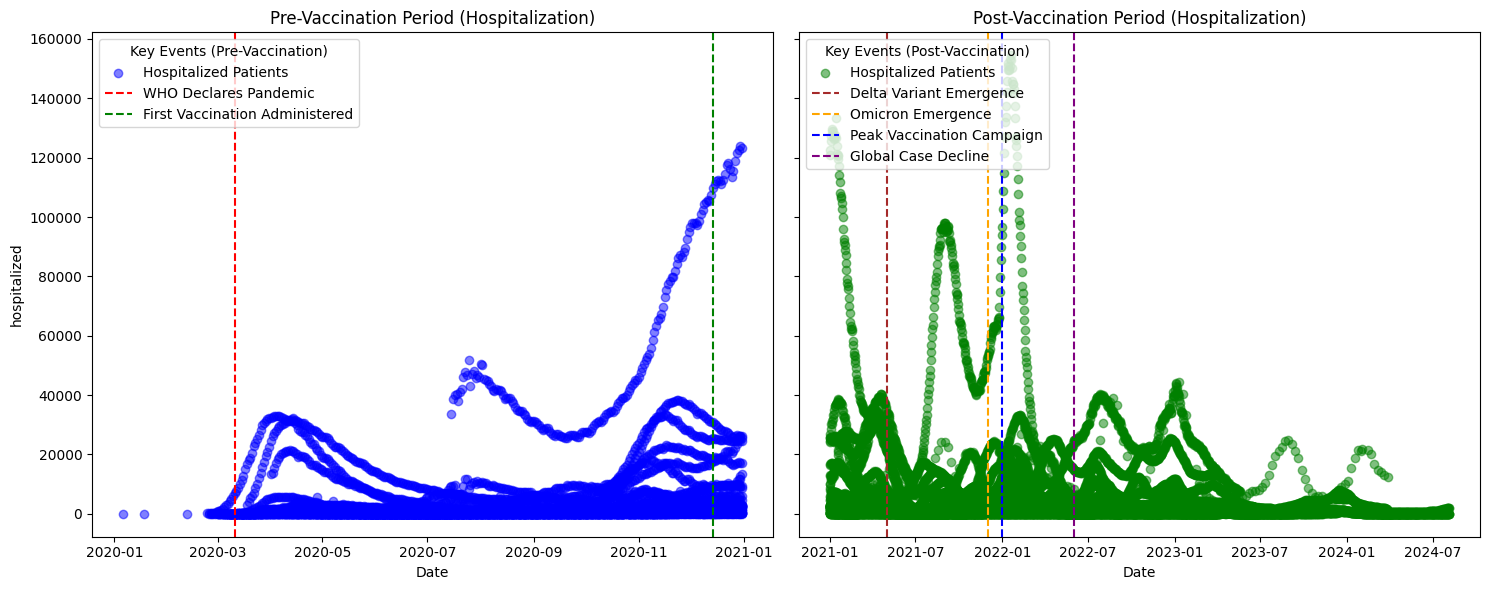

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

#Scatterplot for pre-vaccination
axes[0].scatter(pre_vaccination['date'], pre_vaccination['hosp_patients'], alpha=0.5, color='blue', label='Hospitalized Patients')
axes[0].set_title("Pre-Vaccination Period (Hospitalization)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("hospitalized")

#Scatterplot for post-vaccination
axes[1].scatter(post_vaccination['date'], post_vaccination['hosp_patients'], alpha=0.5, color='green', label='Hospitalized Patients')
axes[1].set_title("Post-Vaccination Period (Hospitalization)")
axes[1].set_xlabel("Date")

#key events
key_events = {
    '2020-03-11': {'label': 'WHO Declares Pandemic', 'color': 'red', 'subplot': 0},
    '2020-12-14': {'label': 'First Vaccination Administered', 'color': 'green', 'subplot': 0},
    '2021-05-01': {'label': 'Delta Variant Emergence', 'color': 'brown', 'subplot': 1},
    '2021-12-01': {'label': 'Omicron Emergence', 'color': 'orange', 'subplot': 1},
    '2022-01-01': {'label': 'Peak Vaccination Campaign', 'color': 'blue', 'subplot': 1},
    '2022-06-01': {'label': 'Global Case Decline', 'color': 'purple', 'subplot': 1}
}

for date, event_info in key_events.items():
    date_parsed = pd.to_datetime(date)
    subplot_index = event_info['subplot']  
    axes[subplot_index].axvline(
        date_parsed,
        color=event_info['color'],
        linestyle='--',
        label=event_info['label']
    )
axes[0].legend(loc='upper left', title='Key Events (Pre-Vaccination)')
axes[1].legend(loc='upper left', title='Key Events (Post-Vaccination)')

plt.tight_layout()
plt.show()

### Pre vs. Post Vaccination Mortality Rate Scatterplots

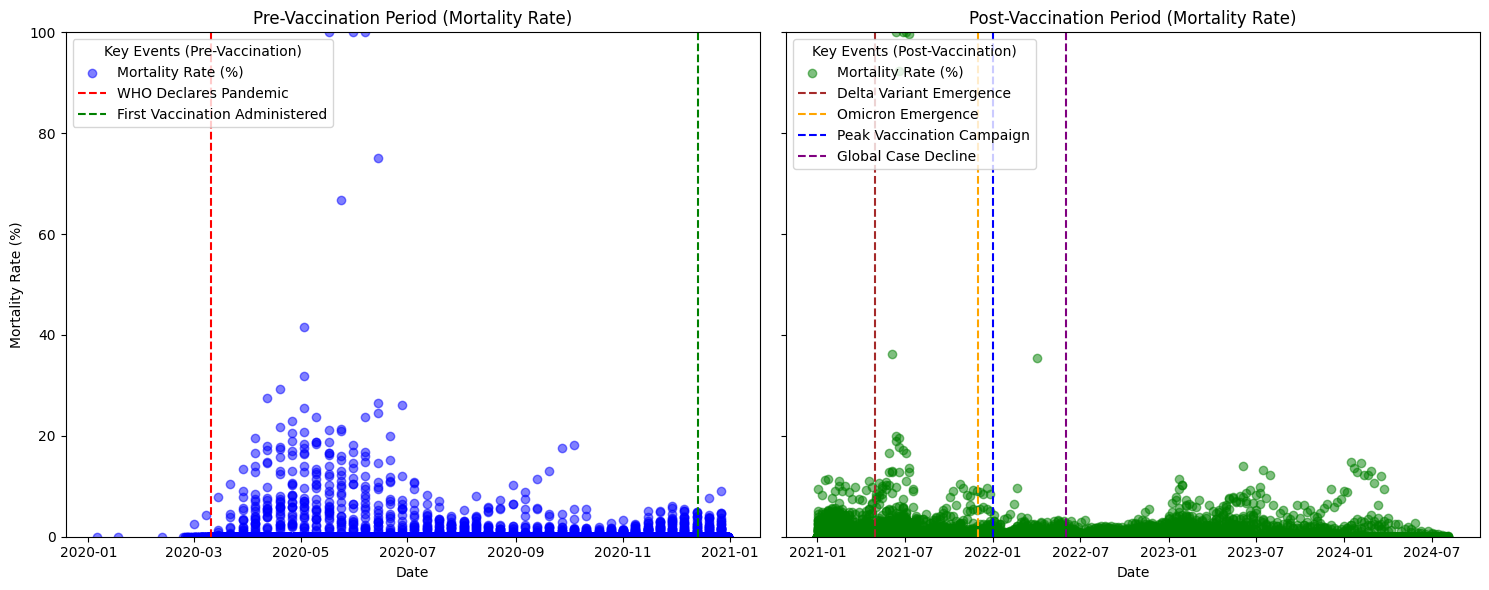

In [12]:
pre_vaccination = pre_vaccination.copy()
post_vaccination = post_vaccination.copy()

#Calculate mortality rate safely
pre_vaccination['mortality_rate'] = (pre_vaccination['new_deaths'] / pre_vaccination['new_cases']) * 100
pre_vaccination['mortality_rate'] = pre_vaccination['mortality_rate'].replace([np.inf, -np.inf], 0).fillna(0)
pre_vaccination['mortality_rate'] = pre_vaccination['mortality_rate'].clip(upper=100)


post_vaccination['mortality_rate'] = (post_vaccination['new_deaths'] / post_vaccination['new_cases']) * 100
post_vaccination['mortality_rate'] = post_vaccination['mortality_rate'].replace([np.inf, -np.inf], 0).fillna(0)
post_vaccination['mortality_rate'] = post_vaccination['mortality_rate'].clip(upper=100)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

#Scatterplot for pre-vaccination
axes[0].scatter(pre_vaccination['date'], pre_vaccination['mortality_rate'], alpha=0.5, color='blue', label='Mortality Rate (%)')
axes[0].set_title("Pre-Vaccination Period (Mortality Rate)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Mortality Rate (%)")
axes[0].set_ylim(0, 100)  

#Scatterplot for post-vaccination 
axes[1].scatter(post_vaccination['date'], post_vaccination['mortality_rate'], alpha=0.5, color='green', label='Mortality Rate (%)')
axes[1].set_title("Post-Vaccination Period (Mortality Rate)")
axes[1].set_xlabel("Date")
axes[1].set_ylim(0, 100)  

#key events
key_events = {
    '2020-03-11': {'label': 'WHO Declares Pandemic', 'color': 'red', 'subplot': 0},
    '2020-12-14': {'label': 'First Vaccination Administered', 'color': 'green', 'subplot': 0},
    '2021-05-01': {'label': 'Delta Variant Emergence', 'color': 'brown', 'subplot': 1},
    '2021-12-01': {'label': 'Omicron Emergence', 'color': 'orange', 'subplot': 1},
    '2022-01-01': {'label': 'Peak Vaccination Campaign', 'color': 'blue', 'subplot': 1},
    '2022-06-01': {'label': 'Global Case Decline', 'color': 'purple', 'subplot': 1}
}

for date, event_info in key_events.items():
    date_parsed = pd.to_datetime(date)
    subplot_index = event_info['subplot']  
    axes[subplot_index].axvline(
        date_parsed,
        color=event_info['color'],
        linestyle='--',
        label=event_info['label']
    )
axes[0].legend(loc='upper left', title='Key Events (Pre-Vaccination)')
axes[1].legend(loc='upper left', title='Key Events (Post-Vaccination)')

plt.tight_layout()
plt.show()
